# Model Evaluation

In this notebook, we evaluate the fine-tuned DistilBERT model on the BANKING77 test dataset.

We will compute:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Top-3 Intent Predictions
- Error Analysis and displaying it

In [1]:
#Importing Libraries
import os
import json
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)

from transformers import(
DistilBertTokenizerFast,
DistilBertForSequenceClassification
)

from sklearn.preprocessing import LabelEncoder

In [2]:
#creating Output Folder
os.makedirs("../outputs", exist_ok = True)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
#Loading Dataset
test_df = pd.read_csv("../Data/test.csv")
test_df

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
...,...,...
3075,"If i'm not in the UK, can I still get a card?",country_support
3076,How many countries do you support?,country_support
3077,What countries do you do business in?,country_support
3078,What are the countries you operate in.,country_support


In [5]:
#Label Encoding
train_df = pd.read_csv("../Data/train.csv")
encoder = LabelEncoder()
encoder.fit(train_df["category"])
test_df["label"] = encoder.transform(test_df["category"])

In [6]:
#Loading the saved model

model = DistilBertForSequenceClassification.from_pretrained(
    "models/saved_model"
)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "models/saved_model"
)
model.to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [12]:
# Creating the Prediction Function

def predict(text):
    inputs = tokenizer(
        text,
        return_tensors = "pt",
        truncation = True,
        padding = True,
        max_length = 64
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim = 1)
    predictions = torch.argmax(probabilities, dim = 1)

    return(
        predictions.item(),
        probabilities.squeeze().cpu().numpy()
    )

In [13]:
#predicting the entire datset

predictions = []
probabilities = []
for text in test_df["text"]:
    pred,prob = predict(text)
    predictions.append(pred)
    probabilities.append(prob)

In [14]:
test_df["prediction"] = predictions

In [16]:
#Accuracy

accuracy = accuracy_score(
    test_df["label"],
    test_df["prediction"]
)
print(f"Accuracy : {accuracy: .4f}")

Accuracy :  0.8594


In [40]:
#Precision

precision = accuracy_score(
    test_df["label"],
    test_df["prediction"]
)
print(f"Precision : {precision: .4f}")

Precision :  0.8594


In [42]:
#Recall

recall = recall_score(
    test_df["label"],
    test_df["prediction"],
    average = "weighted"
)
print(f"Recall : {recall: .4f}")

Recall :  0.8594


In [17]:
# F1 Score

f1 = f1_score(
    test_df["label"],
    test_df["prediction"],
    average = "weighted"
)
print(f"F1 Score : {f1: .4f}")

F1 Score :  0.8520


In [43]:
#Classification Report

report = classification_report(
    test_df["label"],
    test_df["prediction"],
    target_names = encoder.classes_,
    output_dict = True
    
)
report_df = pd.DataFrame(report).transpose()
report_df

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,precision,recall,f1-score,support
Refund_not_showing_up,0.904762,0.950000,0.926829,40.000000
activate_my_card,0.950000,0.950000,0.950000,40.000000
age_limit,0.975610,1.000000,0.987654,40.000000
apple_pay_or_google_pay,1.000000,1.000000,1.000000,40.000000
atm_support,1.000000,0.925000,0.961039,40.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.921053,0.875000,0.897436,40.000000
wrong_exchange_rate_for_cash_withdrawal,1.000000,0.700000,0.823529,40.000000
accuracy,0.859416,0.859416,0.859416,0.859416
macro avg,0.863101,0.859416,0.851995,3080.000000


In [44]:
#Saving Report

report_df.to_csv("../outputs/classification_report.csv", index = True)

In [45]:
#Confusion Matrix

cm = confusion_matrix(
    test_df["label"],
    test_df["prediction"]
)

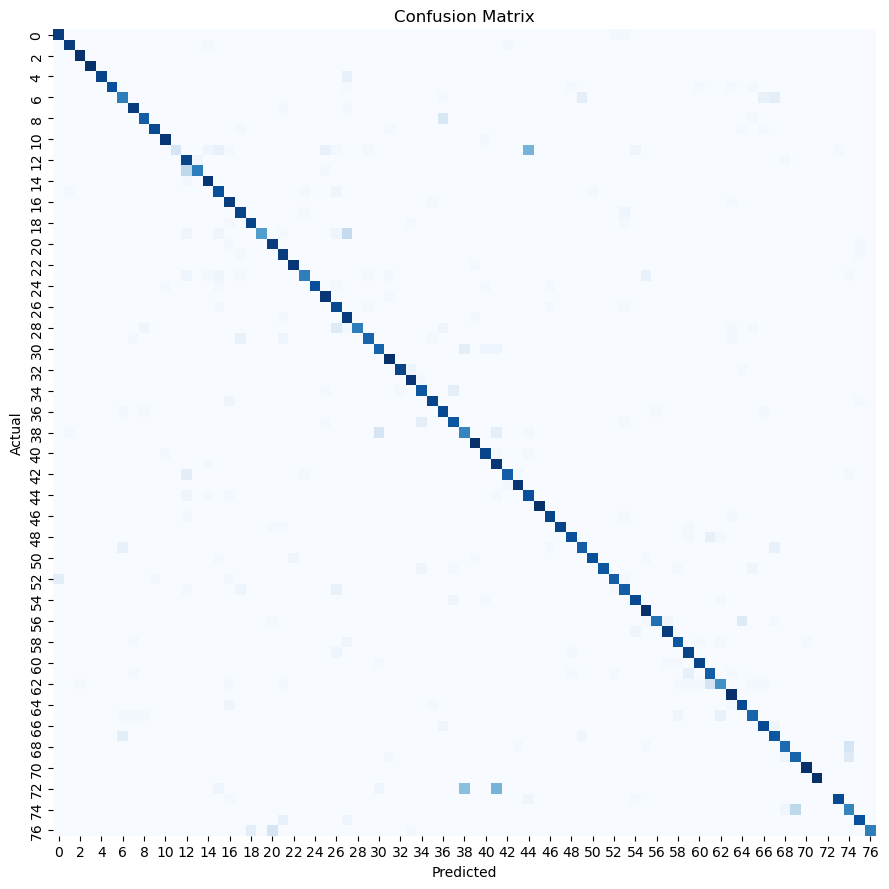

In [46]:
# Plotting Confusion Matrix

plt.figure(figsize = (9,9))
sns.heatmap(
    cm,
    cmap = "Blues",
    cbar = False
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png")

plt.show()

In [47]:
#Saving Metrics

metrics = {
    "Accuracy" : accuracy,
    "Precision" : precision,
    "Recall" : recall,
    "F1 Score" : f1
}
with open("../outputs/metrics.json", "w") as f:
    json.dump(metrics,f,indent = 4)

In [48]:
#Saving Predictions

test_df.to_csv(
    "../outputs/predictions.csv",
    index = False
)

In [54]:
# Top-3 Predictions

top3_predictions = []
for prob in probabilities:
    top3 = np.argsort(prob)[-3:][::-1]
    top3_predictions.append(top3)

In [56]:
#Convert IDs TO Intent Names

reverse_map = dict(
    zip(
        range(len(encoder.classes_)),
        encoder.classes_
    )
)

top3_intents = []
for pred in top3_predictions:
    intents = [reverse_map[i] for i in pred]
    top3_intents.append(intents)

In [58]:
#Saving Top-3 Predictions

top3_df = pd.DataFrame(
    top3_intents,
    columns = [
        "Top1",
        "Top2",
        "Top3"
    ]
)
top3_df.to_csv(
    "../outputs/top3_predictions.csv",
    index = False
)
top3_df.head()

,Top1,Top2,Top3
0,card_arrival,order_physical_card,lost_or_stolen_card
1,card_arrival,card_delivery_estimate,card_linking
2,card_arrival,card_delivery_estimate,order_physical_card
3,card_arrival,card_delivery_estimate,card_about_to_expire
4,card_arrival,card_delivery_estimate,card_about_to_expire


In [59]:
#Error Analysis

errors = test_df[
    test_df["label"] != test_df["prediction"]
]
print("Number of wrong preds: ", len(errors))

Number of wrong preds:  433


In [60]:
#Displaying Errors

errors[
    [
        "text",
        "category",
        "prediction"
    ]
].head(20)

,text,category,prediction
5,When will I get my card?,card_arrival,13
11,How long does a card delivery take?,card_arrival,13
37,Is there tracking info available?,card_arrival,68
66,The app doesn't show the card I received.,card_linking,12
93,Is it a good time to exchange?,exchange_rate,34
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,16
150,the conversion value for my card payments is i...,card_payment_wrong_exchange_rate,53
156,How can I check the exchange rate applied to m...,card_payment_wrong_exchange_rate,33
173,Where did this fee come from?,extra_charge_on_statement,16
189,"I am a new customer, and I happened to look at...",extra_charge_on_statement,16
